## IMPORT LIBRARIES

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import zipfile
import cv2
from PIL import Image
from IPython.display import Markdown, display # Image
from skimage import io
import torch.nn as nn
import torch
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms, models
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, normalize
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import os
import time
%matplotlib inline

In [18]:
# csv with defected parts mask 
defect_parts_mask = pd.read_csv('train.csv')

In [19]:
# constains all imagesID and a label indicating if they are detected or not 
all_img_df = pd.read_csv('defect_and_no_defect.csv')

In [20]:
all_img_df

,ImageID,label
0,0002cc93b.jpg,1
1,0007a71bf.jpg,1
2,000a4bcdd.jpg,1
3,000f6bf48.jpg,1
4,0014fce06.jpg,1
...,...,...
12992,0482ee1d6.jpg,0
12993,04802a6c2.jpg,0
12994,03ae2bc91.jpg,0
12995,04238d7e3.jpg,0


In [21]:
defect_parts_mask

,ImageId,ClassId,EncodedPixels
0,d2291de5c.jpg,1,147963 3 148213 9 148461 18 148711 24 148965 2...
1,78416c3d0.jpg,3,54365 3 54621 7 54877 10 55133 12 55388 14 556...
2,2283f2183.jpg,3,201217 43 201473 128 201729 213 201985 5086 20...
3,f0dc068a8.jpg,3,159207 26 159412 77 159617 128 159822 179 1600...
4,00d639396.jpg,3,229356 17 229595 34 229850 36 230105 37 230360...
...,...,...,...
5743,c12842f5e.jpg,3,88 23 342 29 596 34 850 39 1105 44 1361 46 161...
5744,2222a03b3.jpg,3,63332 4 63587 11 63841 20 64096 27 64351 35 64...
5745,b43ea2c01.jpg,1,185024 7 185279 11 185535 12 185790 13 186045 ...
5746,1bc37a6f4.jpg,3,303867 1 304122 3 304376 6 304613 3 304630 9 3...


In [22]:
print(f'All images Dataset shape: {all_img_df.shape}')
print(f'Masked parts Dataset shape: {defect_parts_mask.shape}')

All images Dataset shape: (12997, 2)
Masked parts Dataset shape: (5748, 3)


## Data Exploration

In [23]:
# add column named `mask`
defect_parts_mask['mask'] = defect_parts_mask['ClassId'].map(lambda x: 1)

In [24]:
plt.style.use('ggplot')

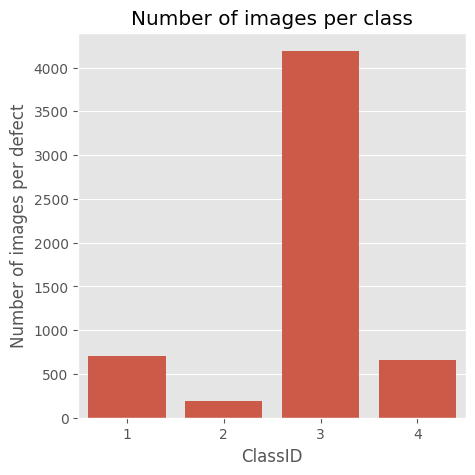

In [25]:
plt.figure(figsize=(5,5))
sns.countplot(data=defect_parts_mask, x='ClassId')
plt.ylabel('Number of images per defect')
plt.xlabel('ClassID')
plt.title('Number of images per class')
plt.show()  

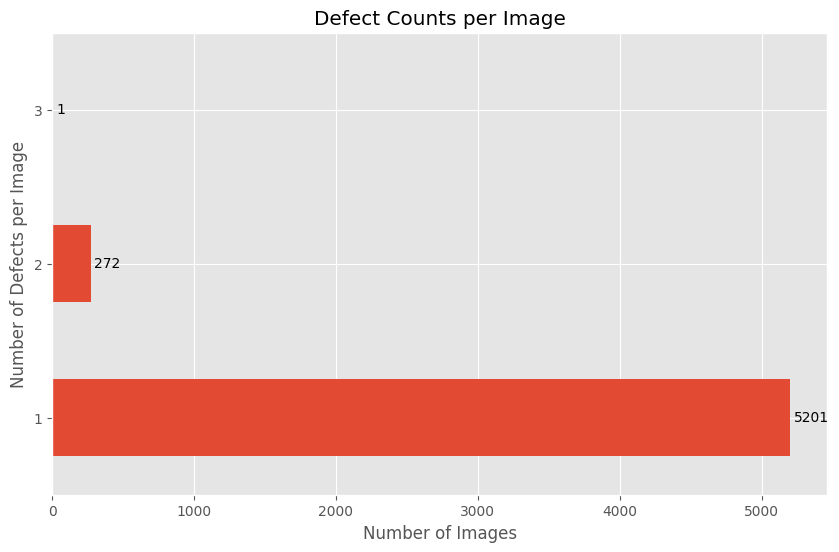

In [26]:
defect_type = defect_parts_mask.groupby(['ImageId'])['mask'].sum()
counts = defect_type.value_counts()

ax = counts.plot(kind='barh', figsize=(10,6))
plt.xlabel('Number of Images')
plt.ylabel('Number of Defects per Image')
plt.title('Defect Counts per Image')
for i, v in enumerate(counts):
    ax.text(v + max(counts)*0.005, i, str(v), va='center')
plt.show()

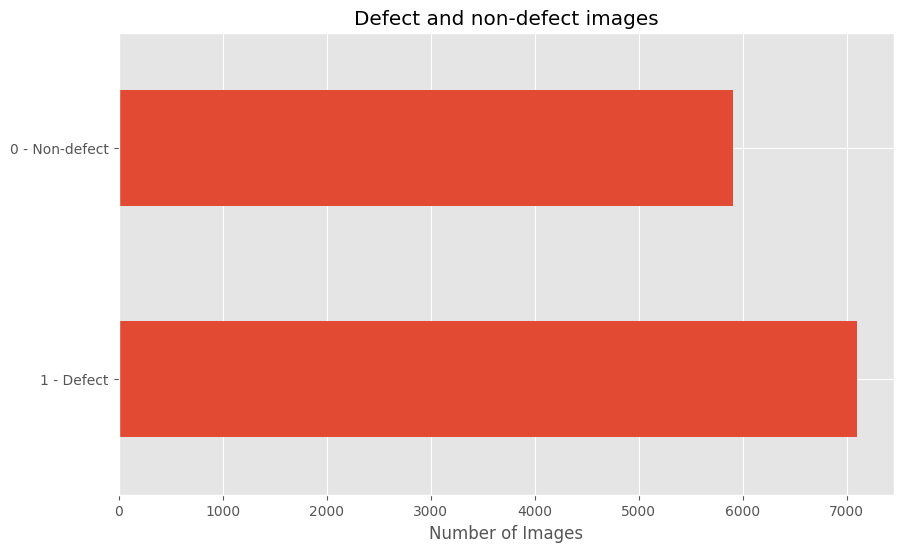

In [27]:
counts = all_img_df.label.value_counts()

label_names = {
    1: '1 - Defect',
    0: '0 - Non-defect'
}

new_labels = [label_names.get(x, str(x)) for x in counts.index]

ax = counts.plot(kind='barh', figsize=(10,6))
plt.xlabel('Number of Images')
plt.ylabel('')  
ax.set_yticklabels(new_labels)
plt.title('Defect and non-defect images')



plt.show()

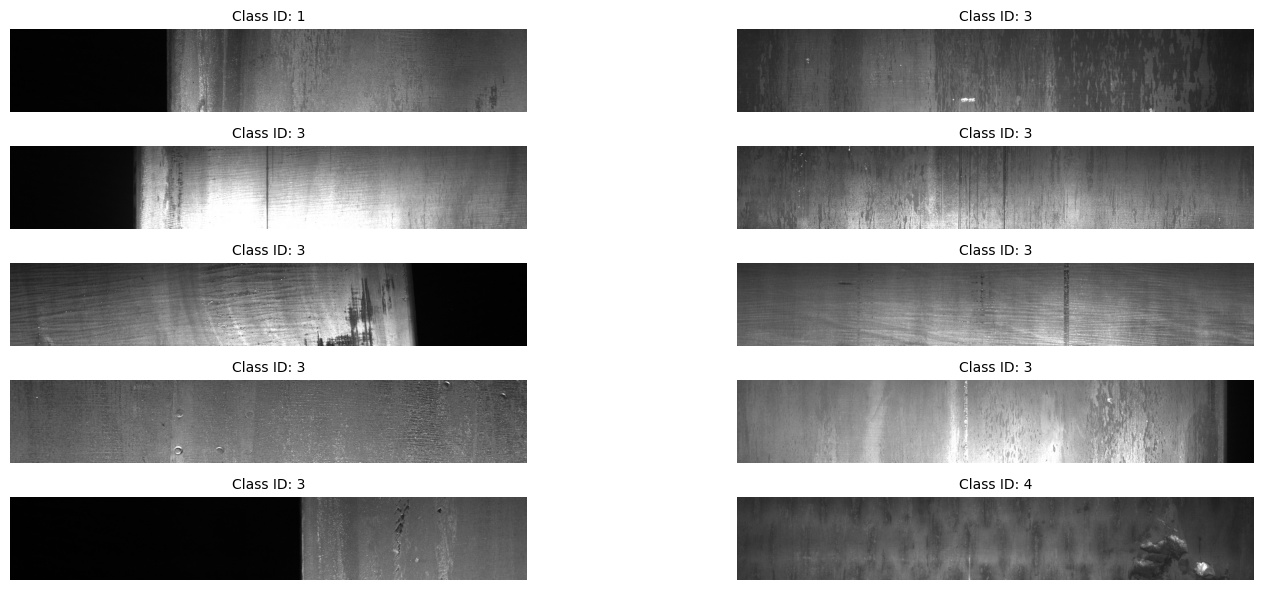

In [28]:
# Display 10 random images

# Directory with all the images
train_dir = r'train_images/'  

plt.style.use('default')
fig, axes = plt.subplots(5, 2, figsize=(15, 6))  
axes = axes.flatten()  

for i in range(10):
    image_id = defect_parts_mask.ImageId.iloc[i]  
    class_id = defect_parts_mask.ClassId.iloc[i]
    
    image_path = os.path.join(train_dir, image_id)
    img = io.imread(image_path)
    axes[i].imshow(img)
    axes[i].set_title(f'Class ID: {class_id}', fontsize=10)
    axes[i].axis("off")  

plt.tight_layout()
plt.show()


In [38]:
#RLE(Run-Length Encoding) Fuctions - Takes string and rebuilds the binary mask.
def mask2rle(img):
    '''
    img: numpy array, 1 - mask, 0 - background
    Returns run length as string formatted
    '''
    # Flatten in column-major order
    pixels = img.flatten()
    pixels = np.concatenate([[0], pixels, [0]])   
    runs = np.where(pixels[1:] != pixels[:-1])[0] + 1
    runs[1::2] -= runs[::2]
    return ' '.join(str(x) for x in runs)


def rle2mask(mask_rle, shape=(256, 1600)):
    '''
    mask_rle: run-length as string formatted (start length pairs)
    shape: (height, width) of the mask to return
    Returns:
        numpy array, shape = (height, width)
        1 = mask, 0 = background
    '''
    # Split the RLE string into a list of numbers
    s = mask_rle.strip().split()

    # Extract start positions and lengths, converting to integer arrays
    starts, lengths = [np.asarray(x, dtype=int) for x in (s[::2], s[1::2])]

    # Convert starts to zero-based indexing
    starts -= 1

    # Calculate end positions for each run
    ends = starts + lengths

    # Create a flat array of zeros (background)
    img = np.zeros(shape[0] * shape[1], dtype=np.uint8)  # shape[0]=height, shape[1]=width

    # Set mask values to 1 within the start-end ranges
    for lo, hi in zip(starts, ends):
        img[lo:hi] = 1

    # Reshape back to (height, width) and transpose to match original orientation
    return img.reshape((shape[1], shape[0])).T  # Transpose to (height, width)

In [30]:
defect_parts_mask.head(3)

,ImageId,ClassId,EncodedPixels,mask
0,d2291de5c.jpg,1,147963 3 148213 9 148461 18 148711 24 148965 2...,1
1,78416c3d0.jpg,3,54365 3 54621 7 54877 10 55133 12 55388 14 556...,1
2,2283f2183.jpg,3,201217 43 201473 128 201729 213 201985 5086 20...,1


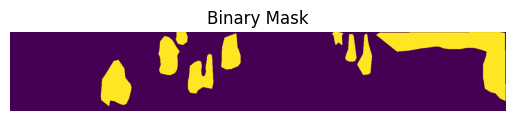

In [15]:
image_index = 641
rle = defect_parts_mask.EncodedPixels[image_index]
mask = rle2mask(rle, shape=(img.shape[0], img.shape[1]))


plt.imshow(mask, cmap='viridis')
plt.title("Binary Mask")
plt.axis("off")  
plt.show()

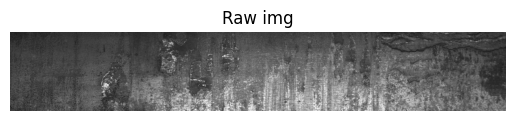

(256, 1600, 3)


In [34]:
img = io.imread(os.path.join(train_dir, defect_parts_mask.ImageId[image_index]))
plt.imshow(img)
plt.title("Raw img")
plt.axis("off")  
plt.show()
print(img.shape)

(np.float64(-0.5), np.float64(1599.5), np.float64(255.5), np.float64(-0.5))

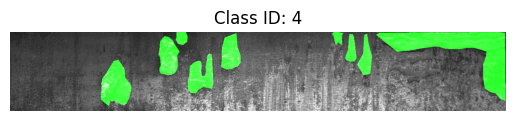

In [35]:
mask = rle2mask(defect_parts_mask.EncodedPixels[image_index], shape=(img.shape[0], img.shape[1]))
img[mask == 1, 1] = 255
plt.imshow(img)
plt.title(f"Class ID: {defect_parts_mask.ClassId[i]}")
plt.axis("off")

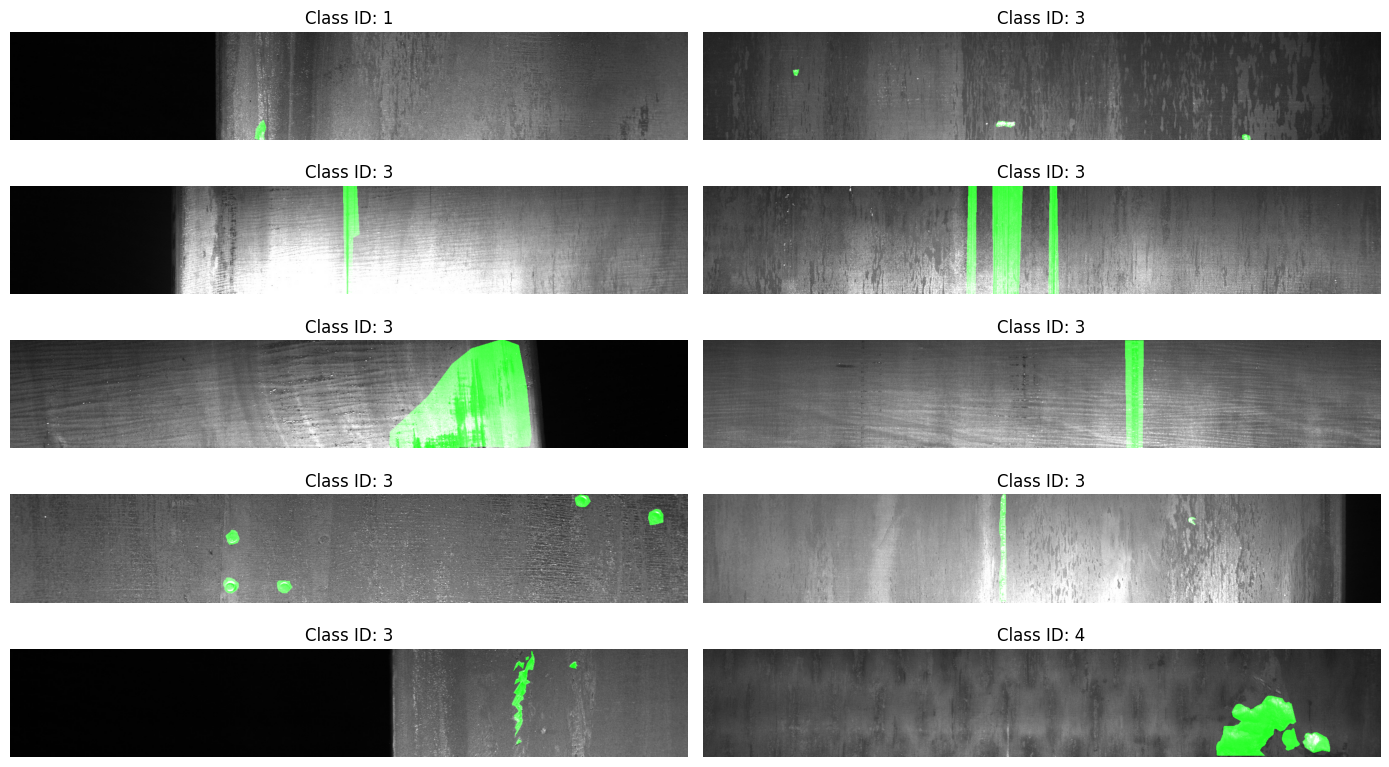

In [90]:
fig, axes = plt.subplots(5, 2, figsize=(14, 8))  
axes = axes.flatten()  

for i in range(10):
    # Open image and convert to RGB
    img = io.imread(os.path.join(train_dir, defect_parts_mask.ImageId[i]))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Get the mask from RLE
    mask = rle2mask(defect_parts_mask.EncodedPixels[i], shape=(img.shape[0], img.shape[1]))
    img[mask == 1, 1] = 255
    axes[i].imshow(img)
    axes[i].set_title(f"Class ID: {defect_parts_mask.ClassId[i]}")
    axes[i].axis("off")

plt.tight_layout()
plt.show()


## CLASSIFICATION MODEL 

In [23]:
# Splitting Data 70% Train, 15% val, 15% test
train_df, temp_df = train_test_split(all_img_df, test_size=0.3, random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42)

In [24]:
train_df.shape

(9097, 2)

In [25]:
test_df.shape

(1950, 2)

In [26]:
val_df.shape

(1950, 2)

In [27]:
train_dir='train_images'

In [28]:
# Dataset Class
class CustomImageDataset(Dataset):
    """
    Custom PyTorch Dataset for loading images from DataFrame.

    Parameters:
        dataframe : DataFrame with image filenames in 'ImageID' column and optional labels in 'label' column.
        img_dir : Directory path to images.
        transform : Transformations to apply to the images.
    

    Returns:
        __getitem__(idx) : tuple or tensor
    """


    
    def __init__(self, dataframe, img_dir, transform=None, has_labels=True):
        self.dataframe = dataframe.reset_index(drop=True)
        self.img_dir = img_dir
        self.transform = transform
        self.has_labels = has_labels

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        img_path = os.path.join(self.img_dir, self.dataframe.loc[idx, "ImageID"])
        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        
        if self.has_labels:
            label = torch.tensor(self.dataframe.loc[idx, "label"], dtype=torch.float32)
            return image, label
        else:
            return image


In [29]:
# Transformations to be applied to the dataset
transform_data = transforms.Compose([
    transforms.Resize((256, 256)),
    #transforms.RandomHorizontalFlip(p=0.5),      
    #transforms.RandomVerticalFlip(p=0.3),       
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])


# apply transformation to sets
train_dataset = CustomImageDataset(dataframe=train_df, img_dir=train_dir, transform=transform_data)
val_dataset = CustomImageDataset(dataframe=val_df, img_dir=train_dir, transform=transform_data)
test_dataset = CustomImageDataset(dataframe=test_df, img_dir=train_dir, transform=transform_data)


#Loads data in batches of 16
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

## Model Setup

### ResNet50 was originally trained by Microsoft Researches. The model was trained on 1.2 million labeled training images and 1,000 different categories  like animals, vehicles, plants, tools, clothing, etc

In [51]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
base_model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
for param in base_model.parameters():
    
    # freeze base model
    param.requires_grad = False  


num_features = base_model.fc.in_features
base_model.fc = nn.Sequential(
    nn.Linear(num_features, 256),
    nn.ReLU(inplace=True),
    nn.Dropout(0.3),
    nn.Linear(256, 1),
    nn.Sigmoid()
)

model = base_model.to(device)


In [52]:
# high level view of model's layers 
def manual_summary(model):
    print("----------------------------------------------------------------")
    print("Layer (type)                 Output Shape              Param #")
    print("================================================================")
    total_params = 0
    for name, module in model.named_modules():
        if not list(module.children()):
            num_params = sum(p.numel() for p in module.parameters() if p.requires_grad)
            total_params += num_params
            print(f"{name:<25} {str('N/A'):<25} {num_params}")
    print("================================================================")
    print(f"Total params: {total_params}")


manual_summary(model)

----------------------------------------------------------------
Layer (type)                 Output Shape              Param #
conv1                     N/A                       0
bn1                       N/A                       0
relu                      N/A                       0
maxpool                   N/A                       0
layer1.0.conv1            N/A                       0
layer1.0.bn1              N/A                       0
layer1.0.conv2            N/A                       0
layer1.0.bn2              N/A                       0
layer1.0.conv3            N/A                       0
layer1.0.bn3              N/A                       0
layer1.0.relu             N/A                       0
layer1.0.downsample.0     N/A                       0
layer1.0.downsample.1     N/A                       0
layer1.1.conv1            N/A                       0
layer1.1.bn1              N/A                       0
layer1.1.conv2            N/A                       0
layer1.1

In [62]:
# Training Setup


# Used for binary classification
criterion = nn.BCELoss()

# only train new layers
optimizer = optim.Adam(model.fc.parameters(), lr=0.001)  


# Early stopping parameters
patience = 20
best_loss = float("inf")
counter = 0
num_epochs = 80

In [63]:
%%time
# Training Loop


train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

for epoch in range(num_epochs):
    # Training Model
    model.train()
    train_loss, train_correct = 0.0, 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device).unsqueeze(1)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * images.size(0)
        preds = (outputs >= 0.5).float()
        train_correct += (preds == labels).sum().item()

    # Validation
    model.eval()
    val_loss, val_correct = 0.0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device).unsqueeze(1)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * images.size(0)
            preds = (outputs >= 0.5).float()
            val_correct += (preds == labels).sum().item()

    # Epoch Metrics
    train_loss /= len(train_loader.dataset)
    val_loss /= len(val_loader.dataset)
    train_acc = train_correct / len(train_loader.dataset)
    val_acc = val_correct / len(val_loader.dataset)

    # Store for plotting
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)

    print(f"Epoch {epoch+1} | "
          f"loss: {train_loss:.4f} - accuracy: {train_acc:.4f} | "
          f"val_loss: {val_loss:.4f} - val_accuracy: {val_acc:.4f}")

    # Early Stopping + Checkpoint
    if val_loss < best_loss:
        best_loss = val_loss
        torch.save(model.state_dict(), "resnet50_best.pth")
        counter = 0
        print("Model improved, saved.")
    else:
        counter += 1
        if counter >= patience:
            print("Early stopping triggered.")
            break


Epoch 1 | loss: 0.3212 - accuracy: 0.8561 | val_loss: 0.2478 - val_accuracy: 0.8990
Model improved, saved.
Epoch 2 | loss: 0.3098 - accuracy: 0.8633 | val_loss: 0.2452 - val_accuracy: 0.9000
Model improved, saved.
Epoch 3 | loss: 0.3045 - accuracy: 0.8612 | val_loss: 0.2324 - val_accuracy: 0.9113
Model improved, saved.
Epoch 4 | loss: 0.2981 - accuracy: 0.8633 | val_loss: 0.2340 - val_accuracy: 0.9154
Epoch 5 | loss: 0.2864 - accuracy: 0.8746 | val_loss: 0.2401 - val_accuracy: 0.9103
Epoch 6 | loss: 0.2955 - accuracy: 0.8671 | val_loss: 0.2180 - val_accuracy: 0.9200
Model improved, saved.
Epoch 7 | loss: 0.2794 - accuracy: 0.8757 | val_loss: 0.2449 - val_accuracy: 0.8995
Epoch 8 | loss: 0.2771 - accuracy: 0.8799 | val_loss: 0.2175 - val_accuracy: 0.9159
Model improved, saved.
Epoch 9 | loss: 0.2701 - accuracy: 0.8812 | val_loss: 0.2363 - val_accuracy: 0.9051
Epoch 10 | loss: 0.2765 - accuracy: 0.8768 | val_loss: 0.2154 - val_accuracy: 0.9185
Model improved, saved.
Epoch 11 | loss: 0.27

## MODEL PERFORMANCE

In [75]:
import matplotlib.pyplot as plt

def plot_training_curves(train_losses, val_losses, train_acc, val_acc):
    epochs = range(1, len(train_losses)+1)

    plt.figure(figsize=(14,5))

    # Loss Plot
    plt.subplot(1, 2, 1)
    plt.plot(epochs, train_losses, label="Train Loss", marker='o')
    plt.plot(epochs, val_losses, label="Validation Loss", marker='o')
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training vs Validation Loss")
    plt.legend()
    if val_losses[-1] > min(val_losses):
        plt.axvline(x=val_losses.index(min(val_losses))+1, color='red', linestyle='--', label='Best Val Loss')
        plt.text(val_losses.index(min(val_losses))+1, max(val_losses), 'Potential overfitting', color='red')
    
    # Accuracy Plot
    plt.subplot(1, 2, 2)
    plt.plot(epochs, train_acc, label="Train Accuracy", marker='o')
    plt.plot(epochs, val_acc, label="Validation Accuracy", marker='o')
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("Training vs Validation Accuracy")
    plt.legend()
    if val_acc[-1] < max(val_acc):
        plt.axvline(x=val_acc.index(max(val_acc))+1, color='red', linestyle='--', label='Peak Val Acc')
        plt.text(val_acc.index(max(val_acc))+1, min(val_acc), 'Potential overfitting', color='red')
    
    plt.tight_layout()
    plt.show()


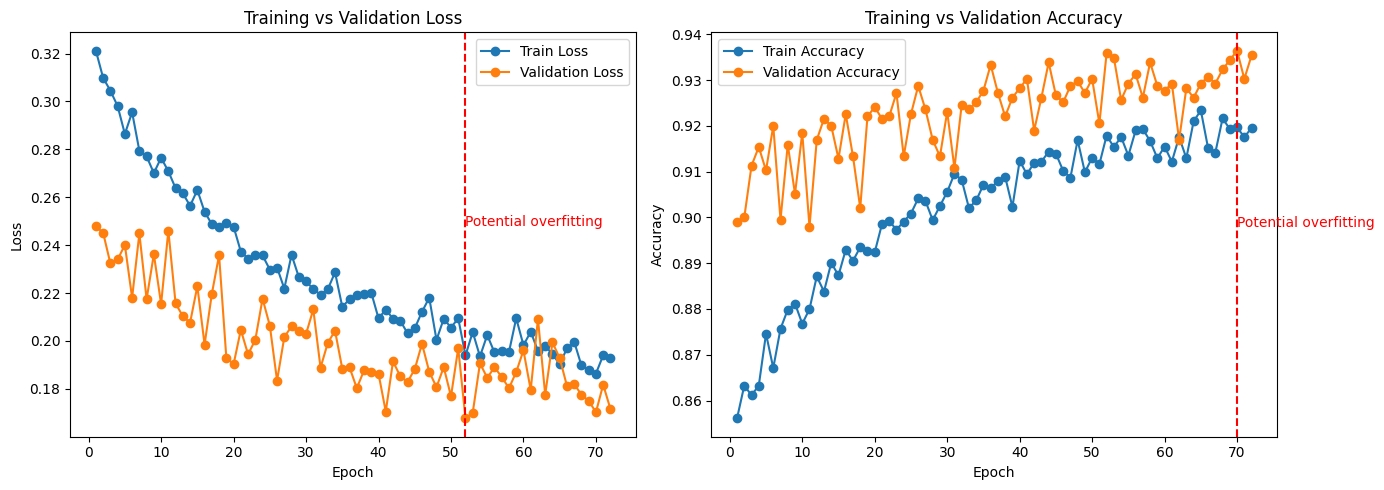

In [76]:
plot_training_curves(train_losses, val_losses, train_accuracies, val_accuracies)


In [60]:
# Save Model

torch.save(base_model.state_dict(), "resnet50_machining_defects.pth")

In [64]:
base_model = models.resnet50(weights=None)
num_features = base_model.fc.in_features
base_model.fc = nn.Sequential(
    nn.Linear(num_features, 256),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(256, 1),
    nn.Sigmoid()
)
loaded_model = base_model

# Loading Model
loaded_model.load_state_dict(torch.load("resnet50_machining_defects.pth", map_location="cpu"))
loaded_model.to(device)
loaded_model.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [65]:
def evaluate_model(model, data_loader, device='cpu', threshold=0.5, plot_cm=True):
    """
    Evaluate model 

    Parameters:
        model : Trained model
        data_loader  : Test or validation data loader
        device : cpu or cuda
        threshold : Threshold for converting raw outputs to binary predictions
        plot_cm : Whether to plot the confusion matrix

    Returns:
        dict: Predictions, binary predictions, labels, accuracy, and classification report
    """
    all_predictions_raw = []
    all_labels = []

    model.eval()
    with torch.no_grad():
        for images, labels in data_loader:
            images = images.to(device)
            outputs = model(images)
            
            predictions = outputs.squeeze().cpu().numpy()
            all_predictions_raw.append(predictions)
            
            all_labels.append(labels.cpu().numpy())

    # Concatenate all batches
    predictions_raw = np.concatenate(all_predictions_raw, axis=0)
    labels = np.concatenate(all_labels, axis=0)

    # Apply threshold to get binary predictions
    predictions_binary = (predictions_raw >= threshold).astype(int)

    # Metrics
    accuracy = accuracy_score(labels, predictions_binary)
    report = classification_report(labels, predictions_binary, labels=[0, 1])
    cm = confusion_matrix(labels, predictions_binary)
    print(f"Accuracy: {accuracy:.4f}\n")
    if plot_cm:
        plt.figure(figsize=(3, 3))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
        plt.title('Confusion Matrix')
        plt.xlabel('Predicted Label')
        plt.ylabel('True Label')
        plt.show()


    
    print("Classification Report:\n", report)

    return {
        "predictions_raw": predictions_raw,
        "predictions_binary": predictions_binary,
        "labels": labels,
        "accuracy": accuracy,
        "classification_report": report,
        "confusion_matrix": cm
    }

Accuracy: 0.9256



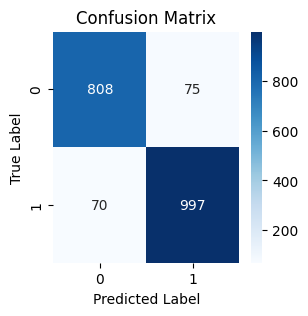

Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.92      0.92       883
           1       0.93      0.93      0.93      1067

    accuracy                           0.93      1950
   macro avg       0.93      0.92      0.92      1950
weighted avg       0.93      0.93      0.93      1950



In [31]:
results = evaluate_model(loaded_model, test_loader, device=device, threshold=0.5)


`True Negatives:` The model correctly predicted 780 parts as not containing defect. </br>
`False Positives:` The model incorrectly predicted 103 parts contained defects that did not have any defects.</br>
`False Negatives:` The model incorrectly predicted 75 parts as not containing defects that actually did contain defects. </br>
`True Positives:` The model correctly predicted 992 parts as not having an defects. </br>

`Precision:` Of the predicted positives, how many were correct.</br>
`Recall:` Of the actual positives, how many the model found.</br>
`F1-score:` Balance between precision and recall.</br>
`Accuracy:` Of all predictions (both classes), how many were correct overall.</br>

Accuracy: 0.8733



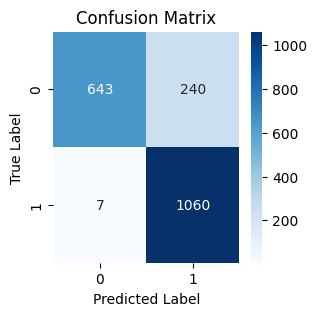

`True Negatives:` The model correctly predicted 780 parts as not containing defect.

`False Positives:` The model incorrectly predicted 103 parts contained defects that did not have any defects.</br>

`False Negatives:` The model incorrectly predicted 75 parts as not containing defects that actually did contain defects. </br>

`True Positives:` The model correctly predicted 992 parts as not having an defects. </br>


Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.73      0.84       883
           1       0.82      0.99      0.90      1067

    accuracy                           0.87      1950
   macro avg       0.90      0.86      0.87      1950
weighted avg       0.89      0.87      0.87      1950



In [78]:
results = evaluate_model(loaded_model, test_loader, device=device, threshold=0.04)

Accuracy: 0.8297



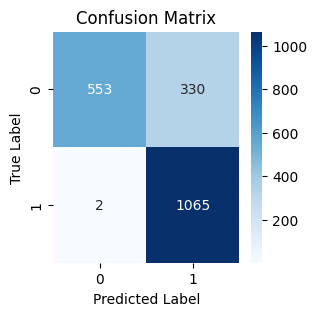

`True Negatives:` The model correctly predicted 780 parts as not containing defect.

`False Positives:` The model incorrectly predicted 103 parts contained defects that did not have any defects.</br>

`False Negatives:` The model incorrectly predicted 75 parts as not containing defects that actually did contain defects. </br>

`True Positives:` The model correctly predicted 992 parts as not having an defects. </br>


Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.63      0.77       883
           1       0.76      1.00      0.87      1067

    accuracy                           0.83      1950
   macro avg       0.88      0.81      0.82      1950
weighted avg       0.87      0.83      0.82      1950



In [79]:
results = evaluate_model(loaded_model, test_loader, device=device, threshold=0.01)

In [32]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from PIL import Image
from sklearn.model_selection import train_test_split
import pandas as pd
import torchvision.transforms as transforms

# =============================
# RLE functions
# =============================

def rle2mask(mask_rle, shape=(256, 1600)):
    if not isinstance(mask_rle, str):
        return torch.zeros(shape, dtype=torch.uint8)
    s = mask_rle.strip().split()
    starts = torch.tensor([int(x) for x in s[::2]], dtype=torch.int64) - 1
    lengths = torch.tensor([int(x) for x in s[1::2]], dtype=torch.int64)
    ends = starts + lengths
    img = torch.zeros(shape[0] * shape[1], dtype=torch.uint8)
    for lo, hi in zip(starts, ends):
        img[lo:hi] = 1
    return img.view(shape[1], shape[0]).t()

# =============================
# Dataset
# =============================

class DefectDataset(Dataset):
    def __init__(self, df, img_dir, transform=None, mask_shape=(256,1600)):
        self.df = df
        self.img_dir = img_dir
        self.transform = transform
        self.mask_shape = mask_shape
        self.image_ids = df['ImageId'].unique()

    def __len__(self):
        return len(self.image_ids)

    def __getitem__(self, idx):
        image_id = self.image_ids[idx]
        img_path = os.path.join(self.img_dir, image_id)
        image = Image.open(img_path).convert("RGB")

        records = self.df[self.df['ImageId'] == image_id]
        mask = torch.zeros(self.mask_shape, dtype=torch.uint8)
        for _, row in records.iterrows():
            mask = torch.maximum(mask, rle2mask(row['EncodedPixels'], self.mask_shape))

        if self.transform:
            image = self.transform(image)

        # Resize mask to 256x256 to match model output
        mask = F.interpolate(mask.unsqueeze(0).unsqueeze(0).float(), size=(256,256), mode='nearest').squeeze(0)
        return image, mask

# =============================
# Minimal ResUNet
# =============================

class ResBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, padding=1)
        self.bn1 = nn.BatchNorm2d(out_ch)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1)
        self.bn2 = nn.BatchNorm2d(out_ch)
        self.shortcut = nn.Conv2d(in_ch, out_ch, 1)
        self.bn_sc = nn.BatchNorm2d(out_ch)

    def forward(self, x):
        sc = self.bn_sc(self.shortcut(x))
        x = F.relu(self.bn1(self.conv1(x)))
        x = self.bn2(self.conv2(x))
        return F.relu(x + sc)

class ResUNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.enc1 = ResBlock(3,16); self.pool1 = nn.MaxPool2d(2)
        self.enc2 = ResBlock(16,32); self.pool2 = nn.MaxPool2d(2)
        self.enc3 = ResBlock(32,64); self.pool3 = nn.MaxPool2d(2)
        self.enc4 = ResBlock(64,128); self.pool4 = nn.MaxPool2d(2)
        self.bottleneck = ResBlock(128,256)

        self.up1 = nn.ConvTranspose2d(256,128,2,2); self.dec1 = ResBlock(256,128)
        self.up2 = nn.ConvTranspose2d(128,64,2,2); self.dec2 = ResBlock(128,64)
        self.up3 = nn.ConvTranspose2d(64,32,2,2); self.dec3 = ResBlock(64,32)
        self.up4 = nn.ConvTranspose2d(32,16,2,2); self.dec4 = ResBlock(32,16)

        self.out_conv = nn.Conv2d(16,1,1)

    def forward(self,x):
        e1 = self.enc1(x); p1 = self.pool1(e1)
        e2 = self.enc2(p1); p2 = self.pool2(e2)
        e3 = self.enc3(p2); p3 = self.pool3(e3)
        e4 = self.enc4(p3); p4 = self.pool4(e4)

        b = self.bottleneck(p4)

        d1 = self.up1(b); d1 = self.dec1(torch.cat([d1,e4],1))
        d2 = self.up2(d1); d2 = self.dec2(torch.cat([d2,e3],1))
        d3 = self.up3(d2); d3 = self.dec3(torch.cat([d3,e2],1))
        d4 = self.up4(d3); d4 = self.dec4(torch.cat([d4,e1],1))

        return torch.sigmoid(self.out_conv(d4))

# =============================
# Loss Function
# =============================

def tversky(y_true, y_pred, alpha=0.7, smooth=1.0):
    y_true_f = y_true.view(-1)
    y_pred_f = y_pred.view(-1)
    tp = (y_true_f * y_pred_f).sum()
    fn = (y_true_f * (1 - y_pred_f)).sum()
    fp = ((1 - y_true_f) * y_pred_f).sum()
    return (tp + smooth) / (tp + alpha*fn + (1-alpha)*fp + smooth)

def focal_tversky(y_true, y_pred, gamma=0.75):
    return torch.pow((1 - tversky(y_true,y_pred)), gamma)

# =============================
# Training Loop
# =============================

if __name__ == "__main__":
     # DataFame with ImageId, ClassId, EncodedPixels cols
    df = pd.read_csv("train.csv") 
    img_dir = "train_images"
    train_df, val_df = train_test_split(df, test_size=0.2, random_state=42)

    transform = transforms.Compose([transforms.Resize((256,256)), transforms.ToTensor()])
    train_dataset = DefectDataset(train_df, img_dir, transform)
    val_dataset = DefectDataset(val_df, img_dir, transform)

    train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=4)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = ResUNet().to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

    for epoch in range(5):
        model.train()
        total_loss = 0
        for images, masks in train_loader:
            images, masks = images.to(device), masks.to(device)
            preds = model(images)
            loss = focal_tversky(masks, preds)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        print(f"Epoch {epoch+1}, Loss: {total_loss/len(train_loader):.4f}")



Epoch 1, Loss: 0.6105
Epoch 2, Loss: 0.5447
Epoch 3, Loss: 0.5200
Epoch 4, Loss: 0.5110
Epoch 5, Loss: 0.4978


In [34]:
import torch
import torch.nn.functional as F
from torchvision import transforms
from PIL import Image

# Example image path
img_path = r"E:\Data\CNC\Production-Defects\train_images\000a4bcdd.jpg"

# Load image
transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor()
])
image = transform(Image.open(img_path).convert("RGB")).unsqueeze(0)  # add batch dim

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.eval()
model.to(device)
image = image.to(device)

with torch.no_grad():
    pred = model(image)  # shape: (1,1,256,256)

# Threshold to binary mask
mask_bin = (pred > 0.5).float()  # 0 or 1
mask_bin = mask_bin.cpu()  # move to CPU
mask_bin = F.interpolate(mask_bin, size=(256,1600), mode='nearest')  # resize to original RLE shape
mask_bin = mask_bin.squeeze(0).squeeze(0)  # remove batch & channel dim

# Convert to RLE
def mask2rle(img):
    pixels = img.numpy().T.flatten()
    pixels = np.concatenate([[0], pixels, [0]])
    runs = np.where(pixels[1:] != pixels[:-1])[0] + 1
    runs[1::2] -= runs[::2]
    return ' '.join(str(x) for x in runs)

rle_pred = mask2rle(mask_bin)
print("Predicted RLE:", rle_pred)


Predicted RLE: 75401 17 75419 16 75437 2 75443 1 75657 17 75675 16 75693 2 75699 1 75913 17 75931 16 75949 2 75955 1 76169 17 76187 16 76205 2 76211 1 76425 17 76443 16 76461 2 76467 1 76681 17 76699 16 76717 2 76723 1 76935 66 77191 66 77447 66 77703 66 77959 66 78215 66 78471 66 78727 85 78983 85 79239 85 79495 85 79751 85 80007 85 80264 85 80520 85 80776 85 81032 85 81288 85 81544 85 81834 1 81843 40 82090 1 82099 40 82346 1 82355 40 82602 1 82611 40 82858 1 82867 40 83114 1 83123 40 83399 1 83406 2 83409 6 83655 1 83662 2 83665 6 83911 1 83918 2 83921 6 84167 1 84174 2 84177 6 84423 1 84430 2 84433 6 84679 1 84686 2 84689 6 84935 1 84942 2 84945 6 88277 8 88533 8 88789 8 89045 8 89301 8 89557 8 89813 8 90069 8 90325 8 90581 8 90837 8 91093 8 91349 8 91605 8 91861 8 92117 8 92373 8 92629 8 92885 8 259513 4 259769 4 260025 4 260281 4 260537 4 260793 4 261047 8 261303 8 261559 8 261815 8 262071 8 262327 8 262586 3 262842 3 263098 3 263354 3 263610 3 263866 3 264122 3


In [52]:
torch.save(model.state_dict(), "resunet-segmentation-model.pth")

In [55]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from PIL import Image
from sklearn.model_selection import train_test_split
import pandas as pd
import torchvision.transforms as transforms
import numpy as np

# =============================
# RLE functions
# =============================
def rle2mask(mask_rle, shape=(256, 1600)):
    if not isinstance(mask_rle, str):
        return torch.zeros(shape, dtype=torch.uint8)
    s = mask_rle.strip().split()
    starts = torch.tensor([int(x) for x in s[::2]], dtype=torch.int64) - 1
    lengths = torch.tensor([int(x) for x in s[1::2]], dtype=torch.int64)
    ends = starts + lengths
    img = torch.zeros(shape[0] * shape[1], dtype=torch.uint8)
    for lo, hi in zip(starts, ends):
        img[lo:hi] = 1
    return img.view(shape[1], shape[0]).t()

# =============================
# Dataset
# =============================
class DefectDataset(Dataset):
    def __init__(self, df, img_dir, transform=None, mask_shape=(256,1600)):
        self.df = df
        self.img_dir = img_dir
        self.transform = transform
        self.mask_shape = mask_shape
        self.image_ids = df['ImageId'].unique()

    def __len__(self):
        return len(self.image_ids)

    def __getitem__(self, idx):
        image_id = self.image_ids[idx]
        img_path = os.path.join(self.img_dir, image_id)
        image = Image.open(img_path).convert("RGB")

        records = self.df[self.df['ImageId'] == image_id]
        mask = torch.zeros(self.mask_shape, dtype=torch.uint8)
        for _, row in records.iterrows():
            mask = torch.maximum(mask, rle2mask(row['EncodedPixels'], self.mask_shape))

        if self.transform:
            image = self.transform(image)

        mask = F.interpolate(mask.unsqueeze(0).unsqueeze(0).float(), size=(256,256), mode='nearest').squeeze(0)
        return image, mask

# =============================
# Minimal ResUNet
# =============================
class ResBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, padding=1)
        self.bn1 = nn.BatchNorm2d(out_ch)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1)
        self.bn2 = nn.BatchNorm2d(out_ch)
        self.shortcut = nn.Conv2d(in_ch, out_ch, 1)
        self.bn_sc = nn.BatchNorm2d(out_ch)

    def forward(self, x):
        sc = self.bn_sc(self.shortcut(x))
        x = F.relu(self.bn1(self.conv1(x)))
        x = self.bn2(self.conv2(x))
        return F.relu(x + sc)

class ResUNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.enc1 = ResBlock(3,16); self.pool1 = nn.MaxPool2d(2)
        self.enc2 = ResBlock(16,32); self.pool2 = nn.MaxPool2d(2)
        self.enc3 = ResBlock(32,64); self.pool3 = nn.MaxPool2d(2)
        self.enc4 = ResBlock(64,128); self.pool4 = nn.MaxPool2d(2)
        self.bottleneck = ResBlock(128,256)

        self.up1 = nn.ConvTranspose2d(256,128,2,2); self.dec1 = ResBlock(256,128)
        self.up2 = nn.ConvTranspose2d(128,64,2,2); self.dec2 = ResBlock(128,64)
        self.up3 = nn.ConvTranspose2d(64,32,2,2); self.dec3 = ResBlock(64,32)
        self.up4 = nn.ConvTranspose2d(32,16,2,2); self.dec4 = ResBlock(32,16)

        self.out_conv = nn.Conv2d(16,1,1)

    def forward(self,x):
        e1 = self.enc1(x); p1 = self.pool1(e1)
        e2 = self.enc2(p1); p2 = self.pool2(e2)
        e3 = self.enc3(p2); p3 = self.pool3(e3)
        e4 = self.enc4(p3); p4 = self.pool4(e4)
        b = self.bottleneck(p4)
        d1 = self.up1(b); d1 = self.dec1(torch.cat([d1,e4],1))
        d2 = self.up2(d1); d2 = self.dec2(torch.cat([d2,e3],1))
        d3 = self.up3(d2); d3 = self.dec3(torch.cat([d3,e2],1))
        d4 = self.up4(d3); d4 = self.dec4(torch.cat([d4,e1],1))
        return torch.sigmoid(self.out_conv(d4))

# =============================
# Loss
# =============================
def tversky(y_true, y_pred, alpha=0.7, smooth=1.0):
    y_true_f = y_true.view(-1)
    y_pred_f = y_pred.view(-1)
    tp = (y_true_f * y_pred_f).sum()
    fn = (y_true_f * (1 - y_pred_f)).sum()
    fp = ((1 - y_true_f) * y_pred_f).sum()
    return (tp + smooth) / (tp + alpha*fn + (1-alpha)*fp + smooth)

def focal_tversky(y_true, y_pred, gamma=0.75):
    return torch.pow((1 - tversky(y_true,y_pred)), gamma)

# =============================
# EarlyStopping Class
# =============================
class EarlyStopping:
    def __init__(self, patience=20, verbose=False, delta=0, path='best_model.pth'):
        self.patience = patience
        self.verbose = verbose
        self.counter = 0
        self.best_score = None
        self.early_stop = False
        self.delta = delta
        self.path = path

    def __call__(self, val_loss, model):
        score = -val_loss
        if self.best_score is None:
            self.best_score = score
            self.save_checkpoint(model)
        elif score < self.best_score + self.delta:
            self.counter +=1
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_score = score
            self.save_checkpoint(model)
            self.counter = 0

    def save_checkpoint(self, model):
        torch.save(model.state_dict(), self.path)
        if self.verbose:
            print("Saved best model")

# =============================
# Training Loop
# =============================
if __name__ == "__main__":
    df = pd.read_csv("train.csv")
    img_dir = "train_images"
    train_df, val_df = train_test_split(df, test_size=0.2, random_state=42)

    transform = transforms.Compose([transforms.Resize((256,256)), transforms.ToTensor()])
    train_dataset = DefectDataset(train_df, img_dir, transform)
    val_dataset = DefectDataset(val_df, img_dir, transform)

    train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=4)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = ResUNet().to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

    early_stopping = EarlyStopping(patience=20, verbose=True, path="resunet-segmentation-model.pth")

    for epoch in range(50):
        # Training
        model.train()
        total_loss = 0
        for images, masks in train_loader:
            images, masks = images.to(device), masks.to(device)
            preds = model(images)
            loss = focal_tversky(masks, preds)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        avg_train_loss = total_loss/len(train_loader)

        # Validation
        model.eval()
        val_loss_total = 0
        with torch.no_grad():
            for images, masks in val_loader:
                images, masks = images.to(device), masks.to(device)
                preds = model(images)
                loss = focal_tversky(masks, preds)
                val_loss_total += loss.item()
        avg_val_loss = val_loss_total/len(val_loader)

        print(f"Epoch {epoch+1}: Train Loss={avg_train_loss:.4f}, Val Loss={avg_val_loss:.4f}")

        early_stopping(avg_val_loss, model)
        if early_stopping.early_stop:
            print("Early stopping triggered")
            break

    print("Training finished. Best model saved as 'resunet-segmentation-model.pth'")


Epoch 1: Train Loss=0.6300, Val Loss=0.5634
Saved best model
Epoch 2: Train Loss=0.5487, Val Loss=0.5266
Saved best model
Epoch 3: Train Loss=0.5251, Val Loss=0.5184
Saved best model
Epoch 4: Train Loss=0.5123, Val Loss=0.5123
Saved best model
Epoch 5: Train Loss=0.4972, Val Loss=0.5184
Epoch 6: Train Loss=0.4865, Val Loss=0.5049
Saved best model
Epoch 7: Train Loss=0.4835, Val Loss=0.4991
Saved best model
Epoch 8: Train Loss=0.4754, Val Loss=0.4986
Saved best model
Epoch 9: Train Loss=0.4694, Val Loss=0.4971
Saved best model
Epoch 10: Train Loss=0.4642, Val Loss=0.4869
Saved best model
Epoch 11: Train Loss=0.4543, Val Loss=0.5085
Epoch 12: Train Loss=0.4500, Val Loss=0.4838
Saved best model
Epoch 13: Train Loss=0.4507, Val Loss=0.4871
Epoch 14: Train Loss=0.4396, Val Loss=0.4807
Saved best model
Epoch 15: Train Loss=0.4411, Val Loss=0.4845
Epoch 16: Train Loss=0.4344, Val Loss=0.4704
Saved best model
Epoch 17: Train Loss=0.4270, Val Loss=0.4820
Epoch 18: Train Loss=0.4261, Val Loss=0.

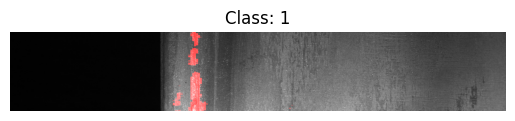

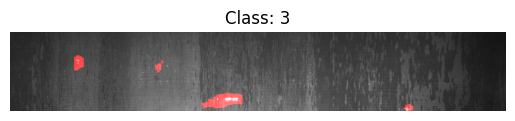

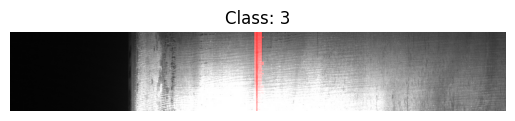

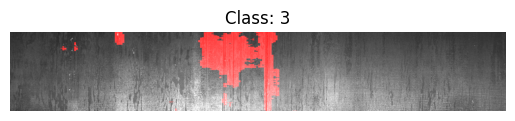

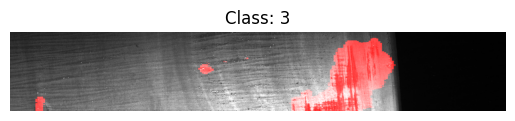

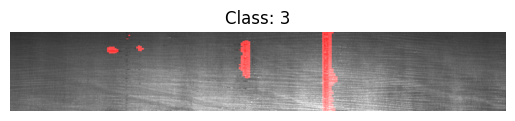

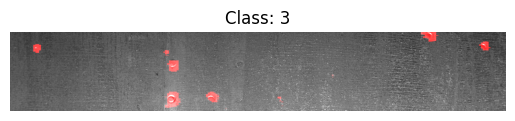

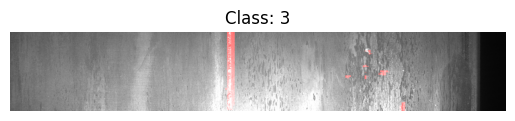

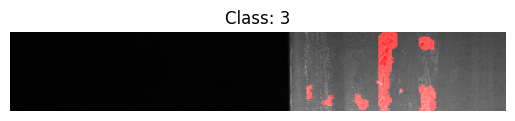

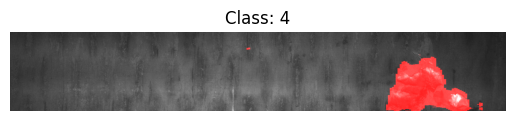

In [61]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import cv2
import os
from skimage import io
import numpy as np

# =============================
# Recreate model architecture
# =============================
class ResBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, padding=1)
        self.bn1 = nn.BatchNorm2d(out_ch)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1)
        self.bn2 = nn.BatchNorm2d(out_ch)
        self.shortcut = nn.Conv2d(in_ch, out_ch, 1)
        self.bn_sc = nn.BatchNorm2d(out_ch)

    def forward(self, x):
        sc = self.bn_sc(self.shortcut(x))
        x = F.relu(self.bn1(self.conv1(x)))
        x = self.bn2(self.conv2(x))
        return F.relu(x + sc)

class ResUNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.enc1 = ResBlock(3,16); self.pool1 = nn.MaxPool2d(2)
        self.enc2 = ResBlock(16,32); self.pool2 = nn.MaxPool2d(2)
        self.enc3 = ResBlock(32,64); self.pool3 = nn.MaxPool2d(2)
        self.enc4 = ResBlock(64,128); self.pool4 = nn.MaxPool2d(2)
        self.bottleneck = ResBlock(128,256)

        self.up1 = nn.ConvTranspose2d(256,128,2,2); self.dec1 = ResBlock(256,128)
        self.up2 = nn.ConvTranspose2d(128,64,2,2); self.dec2 = ResBlock(128,64)
        self.up3 = nn.ConvTranspose2d(64,32,2,2); self.dec3 = ResBlock(64,32)
        self.up4 = nn.ConvTranspose2d(32,16,2,2); self.dec4 = ResBlock(32,16)

        self.out_conv = nn.Conv2d(16,1,1)

    def forward(self,x):
        e1 = self.enc1(x); p1 = self.pool1(e1)
        e2 = self.enc2(p1); p2 = self.pool2(e2)
        e3 = self.enc3(p2); p3 = self.pool3(e3)
        e4 = self.enc4(p3); p4 = self.pool4(e4)
        b = self.bottleneck(p4)
        d1 = self.up1(b); d1 = self.dec1(torch.cat([d1,e4],1))
        d2 = self.up2(d1); d2 = self.dec2(torch.cat([d2,e3],1))
        d3 = self.up3(d2); d3 = self.dec3(torch.cat([d3,e2],1))
        d4 = self.up4(d3); d4 = self.dec4(torch.cat([d4,e1],1))
        return torch.sigmoid(self.out_conv(d4))

# =============================
# Load model weights
# =============================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = ResUNet().to(device)
model.load_state_dict(torch.load("resunet-segmentation-model.pth", map_location=device))
model.eval()

# =============================
# RLE to mask function
# =============================
def rle2mask(mask_rle, height, width):
    if not isinstance(mask_rle, str):
        return np.zeros((height, width), dtype=np.uint8)
    s = mask_rle.strip().split()
    starts = np.array(s[::2], dtype=int) - 1
    lengths = np.array(s[1::2], dtype=int)
    ends = starts + lengths
    img = np.zeros(height*width, dtype=np.uint8)
    for lo, hi in zip(starts, ends):
        img[lo:hi] = 1
    return img.reshape(width, height).T

# =============================
# Visualize predictions
# =============================
import pandas as pd
df_pred = pd.read_csv("train.csv")  # same CSV you used for training

directory = "train_images"  # folder with images

for i in range(10):
    # Load and preprocess image
    img_path = os.path.join(directory, df_pred.ImageId[i])
    img_cv = io.imread(img_path)
    img_rgb = cv2.cvtColor(img_cv, cv2.COLOR_BGR2RGB)
    
    # Prepare input for model
    img_tensor = torch.tensor(img_rgb).permute(2,0,1).unsqueeze(0).float()/255.0
    img_tensor = F.interpolate(img_tensor, size=(256,256), mode='bilinear').to(device)
    
    # Get prediction
    with torch.no_grad():
        pred = model(img_tensor)
    mask_pred = (pred > 0.5).cpu().squeeze().numpy().astype(np.uint8)
    mask_pred = cv2.resize(mask_pred, (img_rgb.shape[1], img_rgb.shape[0]), interpolation=cv2.INTER_NEAREST)
    
    # Overlay mask on image
    img_rgb[mask_pred==1,0] = 255
    
    # Plot
    plt.figure()
    plt.title(f"Class: {df_pred.ClassId[i]}")
    plt.imshow(img_rgb)
    plt.axis('off')
    plt.show()


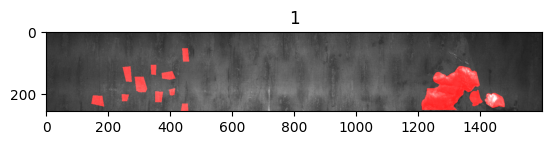

In [60]:
  mask = rle2mask(df_pred.EncodedPixels[3854],img.shape[0],img.shape[1])
  
  img[mask == 1,0] = 255
  plt.figure()
  plt.title(df_pred.ClassId[3854])
  plt.imshow(img)

In [74]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from PIL import Image
from sklearn.model_selection import train_test_split
import pandas as pd
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt

# =============================
# RLE Functions
# =============================

def rle2mask(mask_rle, height=256, width=1600):
    if not isinstance(mask_rle, str):
        return torch.zeros((height, width), dtype=torch.uint8)
    s = mask_rle.strip().split()
    starts = torch.tensor([int(x) for x in s[::2]], dtype=torch.int64) - 1
    lengths = torch.tensor([int(x) for x in s[1::2]], dtype=torch.int64)
    ends = starts + lengths
    img = torch.zeros(height * width, dtype=torch.uint8)
    for lo, hi in zip(starts, ends):
        img[lo:hi] = 1
    return img.view(width, height).t()  # transpose to (height, width)

# =============================
# Dataset
# =============================

class DefectDataset(Dataset):
    def __init__(self, df, img_dir, transform=None, mask_shape=(256,1600)):
        self.df = df
        self.img_dir = img_dir
        self.transform = transform
        self.mask_shape = mask_shape
        self.image_ids = df['ImageId'].unique()

    def __len__(self):
        return len(self.image_ids)

    def __getitem__(self, idx):
        image_id = self.image_ids[idx]
        img_path = os.path.join(self.img_dir, image_id)
        image = Image.open(img_path).convert("RGB")

        records = self.df[self.df['ImageId'] == image_id]
        mask = torch.zeros((self.mask_shape[0], self.mask_shape[1]), dtype=torch.uint8)
        for _, row in records.iterrows():
            mask = torch.maximum(mask, rle2mask(row['EncodedPixels'], height=self.mask_shape[0], width=self.mask_shape[1]))

        if self.transform:
            image = self.transform(image)

        # Resize mask to 256x256 to match model output
        mask = F.interpolate(mask.unsqueeze(0).unsqueeze(0).float(), size=(256,256), mode='nearest').squeeze(0)
        return image, mask

# =============================
# Minimal ResUNet
# =============================

class ResBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, padding=1)
        self.bn1 = nn.BatchNorm2d(out_ch)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1)
        self.bn2 = nn.BatchNorm2d(out_ch)
        self.shortcut = nn.Conv2d(in_ch, out_ch, 1)
        self.bn_sc = nn.BatchNorm2d(out_ch)

    def forward(self, x):
        sc = self.bn_sc(self.shortcut(x))
        x = F.relu(self.bn1(self.conv1(x)))
        x = self.bn2(self.conv2(x))
        return F.relu(x + sc)

class ResUNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.enc1 = ResBlock(3,16); self.pool1 = nn.MaxPool2d(2)
        self.enc2 = ResBlock(16,32); self.pool2 = nn.MaxPool2d(2)
        self.enc3 = ResBlock(32,64); self.pool3 = nn.MaxPool2d(2)
        self.enc4 = ResBlock(64,128); self.pool4 = nn.MaxPool2d(2)
        self.bottleneck = ResBlock(128,256)

        self.up1 = nn.ConvTranspose2d(256,128,2,2); self.dec1 = ResBlock(256,128)
        self.up2 = nn.ConvTranspose2d(128,64,2,2); self.dec2 = ResBlock(128,64)
        self.up3 = nn.ConvTranspose2d(64,32,2,2); self.dec3 = ResBlock(64,32)
        self.up4 = nn.ConvTranspose2d(32,16,2,2); self.dec4 = ResBlock(32,16)

        self.out_conv = nn.Conv2d(16,1,1)

    def forward(self,x):
        e1 = self.enc1(x); p1 = self.pool1(e1)
        e2 = self.enc2(p1); p2 = self.pool2(e2)
        e3 = self.enc3(p2); p3 = self.pool3(e3)
        e4 = self.enc4(p3); p4 = self.pool4(e4)

        b = self.bottleneck(p4)

        d1 = self.up1(b); d1 = self.dec1(torch.cat([d1,e4],1))
        d2 = self.up2(d1); d2 = self.dec2(torch.cat([d2,e3],1))
        d3 = self.up3(d2); d3 = self.dec3(torch.cat([d3,e2],1))
        d4 = self.up4(d3); d4 = self.dec4(torch.cat([d4,e1],1))

        return torch.sigmoid(self.out_conv(d4))

# =============================
# Loss Function
# =============================

def tversky(y_true, y_pred, alpha=0.7, smooth=1.0):
    y_true_f = y_true.view(-1)
    y_pred_f = y_pred.view(-1)
    tp = (y_true_f * y_pred_f).sum()
    fn = (y_true_f * (1 - y_pred_f)).sum()
    fp = ((1 - y_true_f) * y_pred_f).sum()
    return (tp + smooth) / (tp + alpha*fn + (1-alpha)*fp + smooth)

def focal_tversky(y_true, y_pred, gamma=0.75):
    return torch.pow((1 - tversky(y_true,y_pred)), gamma)

# =============================
# Training Loop with Early Stopping
# =============================

from torch.optim import Adam

def train_model(model, train_loader, val_loader, device, epochs=20, patience=5):
    optimizer = Adam(model.parameters(), lr=1e-3)
    best_loss = float('inf')
    patience_counter = 0

    for epoch in range(epochs):
        model.train()
        total_loss = 0
        for images, masks in train_loader:
            images, masks = images.to(device), masks.to(device)
            preds = model(images)
            loss = focal_tversky(masks, preds)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        avg_train_loss = total_loss / len(train_loader)

        # Validation
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for images, masks in val_loader:
                images, masks = images.to(device), masks.to(device)
                preds = model(images)
                loss = focal_tversky(masks, preds)
                val_loss += loss.item()
        avg_val_loss = val_loss / len(val_loader)

        print(f"Epoch {epoch+1} - Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}")

        # Early stopping
        if avg_val_loss < best_loss:
            best_loss = avg_val_loss
            patience_counter = 0
            torch.save(model.state_dict(), "resunet-segmentation-model.pth")
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print("Early stopping triggered!")
                break

# =============================
# Evaluation Function
# =============================

def evaluate_model(model, val_loader, device):
    model.eval()
    tversky_scores = []

    with torch.no_grad():
        for images, masks in val_loader:
            images, masks = images.to(device), masks.to(device)
            preds = model(images)
            score = tversky(masks, preds).item()
            tversky_scores.append(score)
    
    avg_score = np.mean(tversky_scores)
    print(f"Average Tversky Score on Validation Set: {avg_score:.4f}")
    return avg_score

# =============================
# Prediction Visualization
# =============================

def visualize_predictions(model, df, img_dir, device, num_images=5):
    model.eval()
    transform = transforms.Compose([transforms.Resize((256,256)), transforms.ToTensor()])
    
    for i, image_id in enumerate(df['ImageId'].unique()[:num_images]):
        img_path = os.path.join(img_dir, image_id)
        image = Image.open(img_path).convert("RGB")
        input_tensor = transform(image).unsqueeze(0).to(device)

        with torch.no_grad():
            pred_mask = model(input_tensor)[0,0].cpu().numpy()
        
        pred_mask_bin = (pred_mask > 0.5).astype(np.uint8)
        pred_mask_resized = cv2.resize(pred_mask_bin, (image.width, image.height), interpolation=cv2.INTER_NEAREST)
        img_np = np.array(image)
        img_np[pred_mask_resized == 1, 0] = 255

        plt.figure()
        plt.title(f"Predicted Mask: {image_id}")
        plt.imshow(img_np)
        plt.axis("off")
        plt.show()

# =============================
# Main Script
# =============================


In [75]:

df = pd.read_csv("train.csv")  # ImageId, ClassId, EncodedPixels
img_dir = "train_images"
train_df, val_df = train_test_split(df, test_size=0.2, random_state=42)

transform = transforms.Compose([transforms.Resize((256,256)), transforms.ToTensor()])
train_dataset = DefectDataset(train_df, img_dir, transform)
val_dataset = DefectDataset(val_df, img_dir, transform)

train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=4)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = ResUNet().to(device)

# Train model
train_model(model, train_loader, val_loader, device, epochs=20, patience=5)



Epoch 1 - Train Loss: 0.6227, Val Loss: 0.5598
Epoch 2 - Train Loss: 0.5572, Val Loss: 0.5451
Epoch 3 - Train Loss: 0.5266, Val Loss: 0.5332
Epoch 4 - Train Loss: 0.5108, Val Loss: 0.5198
Epoch 5 - Train Loss: 0.5063, Val Loss: 0.5299
Epoch 6 - Train Loss: 0.4923, Val Loss: 0.4987
Epoch 7 - Train Loss: 0.4850, Val Loss: 0.4961
Epoch 8 - Train Loss: 0.4748, Val Loss: 0.4945
Epoch 9 - Train Loss: 0.4673, Val Loss: 0.4847
Epoch 10 - Train Loss: 0.4645, Val Loss: 0.4806
Epoch 11 - Train Loss: 0.4584, Val Loss: 0.4987
Epoch 12 - Train Loss: 0.4563, Val Loss: 0.4815
Epoch 13 - Train Loss: 0.4458, Val Loss: 0.4763
Epoch 14 - Train Loss: 0.4449, Val Loss: 0.4738
Epoch 15 - Train Loss: 0.4378, Val Loss: 0.4891
Epoch 16 - Train Loss: 0.4340, Val Loss: 0.4699
Epoch 17 - Train Loss: 0.4309, Val Loss: 0.4804
Epoch 18 - Train Loss: 0.4259, Val Loss: 0.4654
Epoch 19 - Train Loss: 0.4208, Val Loss: 0.4685
Epoch 20 - Train Loss: 0.4207, Val Loss: 0.4668


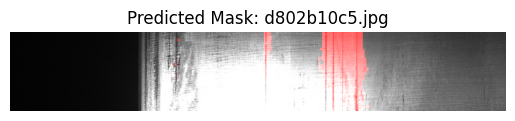

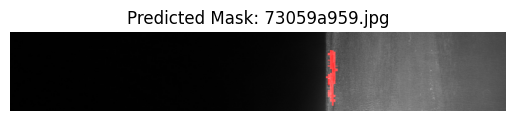

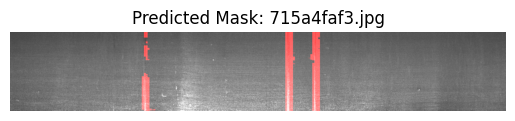

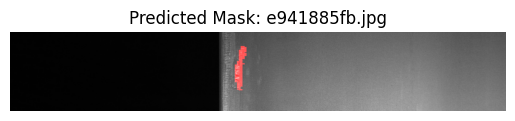

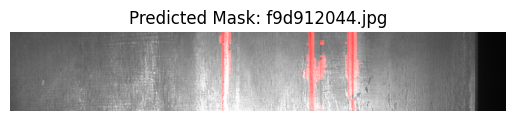

In [76]:

     # Visualize predictions
    visualize_predictions(model, val_df, img_dir, device, num_images=5)


In [78]:
# Evaluate

evaluate_model(model, val_loader, device)

Average Tversky Score on Validation Set: 0.6314


np.float64(0.6314104603047956)

In [86]:
# Predict single image
import torch
import cv2
import matplotlib.pyplot as plt
from torchvision import transforms

# 1. Load your trained model
model = ResUNet().to(device)
model.load_state_dict(torch.load("resunet-segmentation-model.pth", map_location=device))
model.eval()

# 2. Define a transform (resize to match model input)
transform = transforms.Compose([
    transforms.ToTensor(),
])

# 3. Function to predict mask for a single image
def predict_image(img_path, model, device):
    # read image
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    h, w = img.shape[:2]

    # preprocess
    img_tensor = transform(cv2.resize(img, (256, 256)))  # resize to model input
    img_tensor = img_tensor.unsqueeze(0).to(device)

    # predict
    with torch.no_grad():
        pred = model(img_tensor)
        pred = torch.sigmoid(pred)
        pred = (pred > 0.5).float()  # threshold

    # resize prediction back to original image size
    pred_mask = pred.squeeze().cpu().numpy()
    pred_mask = cv2.resize(pred_mask, (w, h))

    return img, pred_mask

# 4. Example usage
image_path = r"E:\Data\CNC\Production-Defects\train_images\002f2671f.jpg"   # replace with an actual filename
orig_img, mask = predict_image(image_path, model, device)

# 5. Visualize
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.title("Original")
plt.imshow(orig_img)
plt.axis("off")

plt.subplot(1,2,2)
plt.title("Predicted Mask")
plt.imshow(mask, cmap="gray")
plt.axis("off")
plt.show()


error: OpenCV(4.12.0) D:\a\opencv-python\opencv-python\opencv\modules\imgproc\src\color.cpp:199: error: (-215:Assertion failed) !_src.empty() in function 'cv::cvtColor'


In [89]:
img = cv2.imread(image_path)
if img is None:
    raise FileNotFoundError(f"Could not load image at {image_path}")
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

FileNotFoundError: Could not load image at E:\Data\CNC\Production-Defects\train_images\002f2671f.jpg

In [88]:
img